# Import

In [1]:
# general import: 
import sys
import time
import os
from pathlib import Path
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# quantum import:
from qiskit import QuantumCircuit
from qiskit.quantum_info import DensityMatrix
from qiskit.visualization import plot_state_city, plot_state_hinton, plot_state_qsphere

In [3]:
# ML import:
import tensorflow as tf
import keras
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
import sklearn
from sklearn.model_selection import train_test_split

In [4]:
# custom helper and libraries:
sys.path.append('../src')
from povm_sampling import *
from statesprep import *
from vae import *
from plots import *
from utils import *
from mle import *

# GHZ 3 qubit

Let's first consider the easy GHZ state for 3 qubits system

# Data

Data creation:

┌───┐          
q_0: ┤ H ├──■────■──
     └───┘┌─┴─┐  │  
q_1: ─────┤ X ├──┼──
          └───┘┌─┴─┐
q_2: ──────────┤ X ├
               └───┘

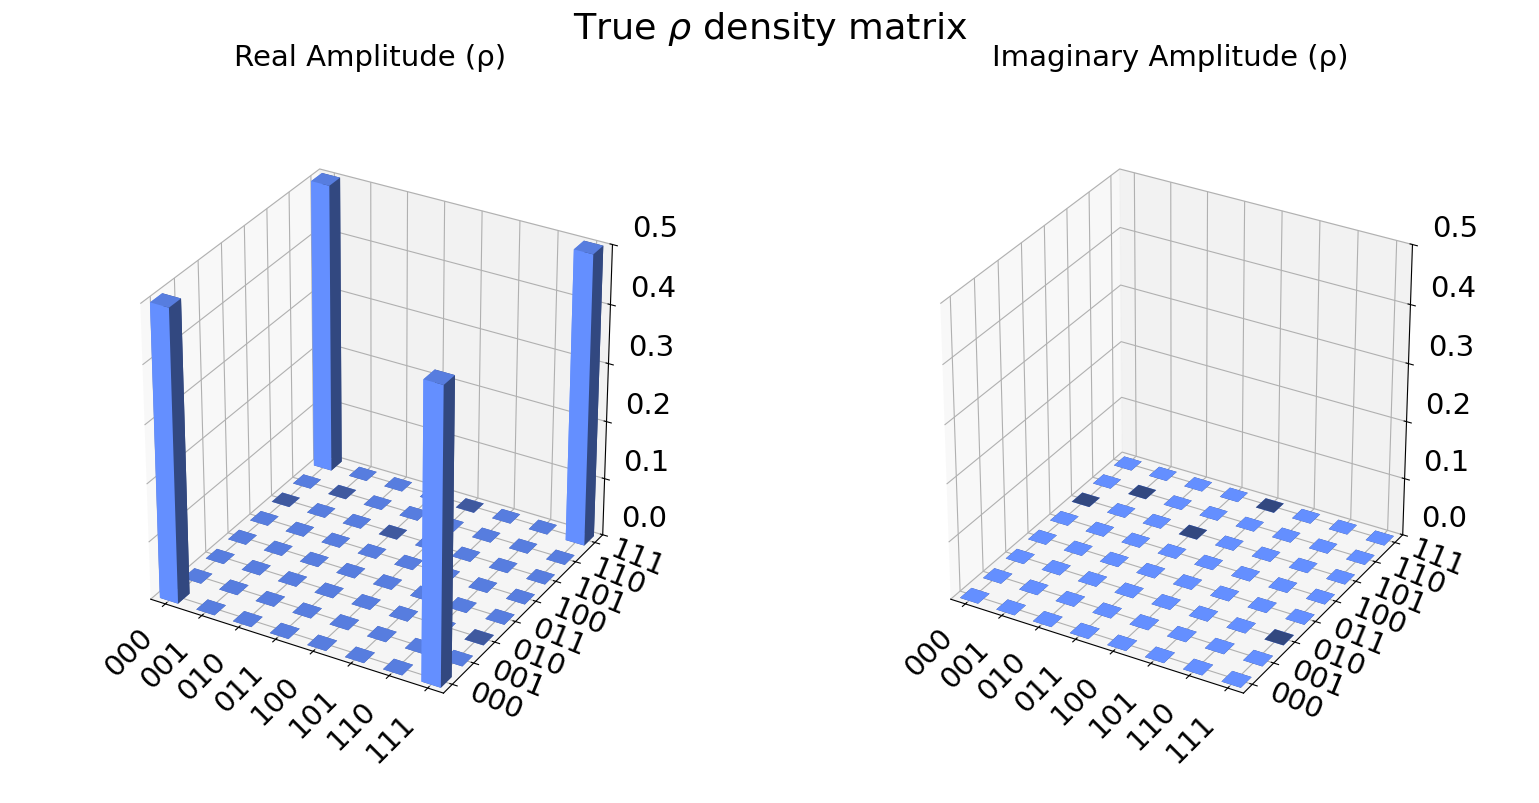

In [5]:
# true state circuit and density matrix
N = 3
qc = create_ghz_state(N)
display(qc.draw())

rho_true = DensityMatrix(qc)
fig = plot_state_city(rho_true, title="True $\\rho$ density matrix")
display(fig)

In [57]:
# create data sampling the true probability distribution
n_samples = 1000
p_exact = povm_probability(rho_true.data, N)
samples = sample_povm(p_exact, n_samples)

# Direct reconstruction

Let's first try to reconstruct the matrix direcly from the inverse Born rule, using the empirical povm measurements distributions instead of the exact ones

In [58]:
# reconstruct density matrix direct from p_sample

# empirical distribution of samples
p_sample = samples_to_empirical_dist(samples, N)

# helper
povm_dict = build_povm(N)
P_vec    = pvec_from_pdict(p_sample, N)
T, T_inv = get_overlap_matrix(N)

# perform inverse Born's rule
rho_sample = reconstruct_rho(P_vec, N, T_inv, povm_dict)

# verify reconstructed rho
validate_rho(rho_sample);

# # plots
# fig = plot_state_city(rho_sample, title='$\\rho$ direct reconstruction')
# display(fig)

# rho_diff = rho_true - rho_sample

# fig = plot_state_city(rho_diff, title="$\\Delta\\rho$: true matrix - direct reconstruction ")
# display(fig)

# fq = quantum_fidelity(rho_true, rho_sample)
# print(f"quantum fidelity F_q = {fq:.6f}")

  Hermitian:          True
  Tr(rho):            1.00000000
  Pos semi-definite:  False  (min eigval = -2.19e-01)


Direct reconstruction leads to un-physical solution.

Density matrix is not semi-pos


Costraint: the possible density matrix must be hermitian, semi-pos

 # Maximum Likelihood Estimator

MLE searches for the best matrix (under constraint) that can be related to the seen samples.

It uses the Cholesky matrix parametrization T(t) to ensure rho semi-pos, hermitian.

In [59]:
# compute density matrix using MLE

# Negative LogLikelihood
nll = make_nll(samples, N)


# creates cholesky params array to initialize minuit
dim = 2**N
init_rho = np.eye(dim, dtype=complex) / dim   # max mixed state
p0 = rho_to_params(init_rho, N)
print(f"Cholesky params to minimize: {count_params(N)}  (= (2^N)^2 )")
print(len(p0), dim**2)


# create Minuit obj
m = Minuit(nll, *p0)
# iminuit built-in to use custom likelihood cost func --> for error estimation m.minos
m.errordef = Minuit.LIKELIHOOD   # = 0.5    
m.print_level = 0

m.migrad()                  
if not m.valid:
    print('not valid!')
    # second try
    m.migrad()
else:
    print('minimization completed!')  
print(f"\nMinuit valid:  {m.valid}")

Cholesky params to minimize: 64  (= (2^N)^2 )
64 64
minimization completed!

Minuit valid:  True


  Hermitian:          True
  Tr(rho):            1.00000000
  Pos semi-definite:  True  (min eigval = 2.80e-11)


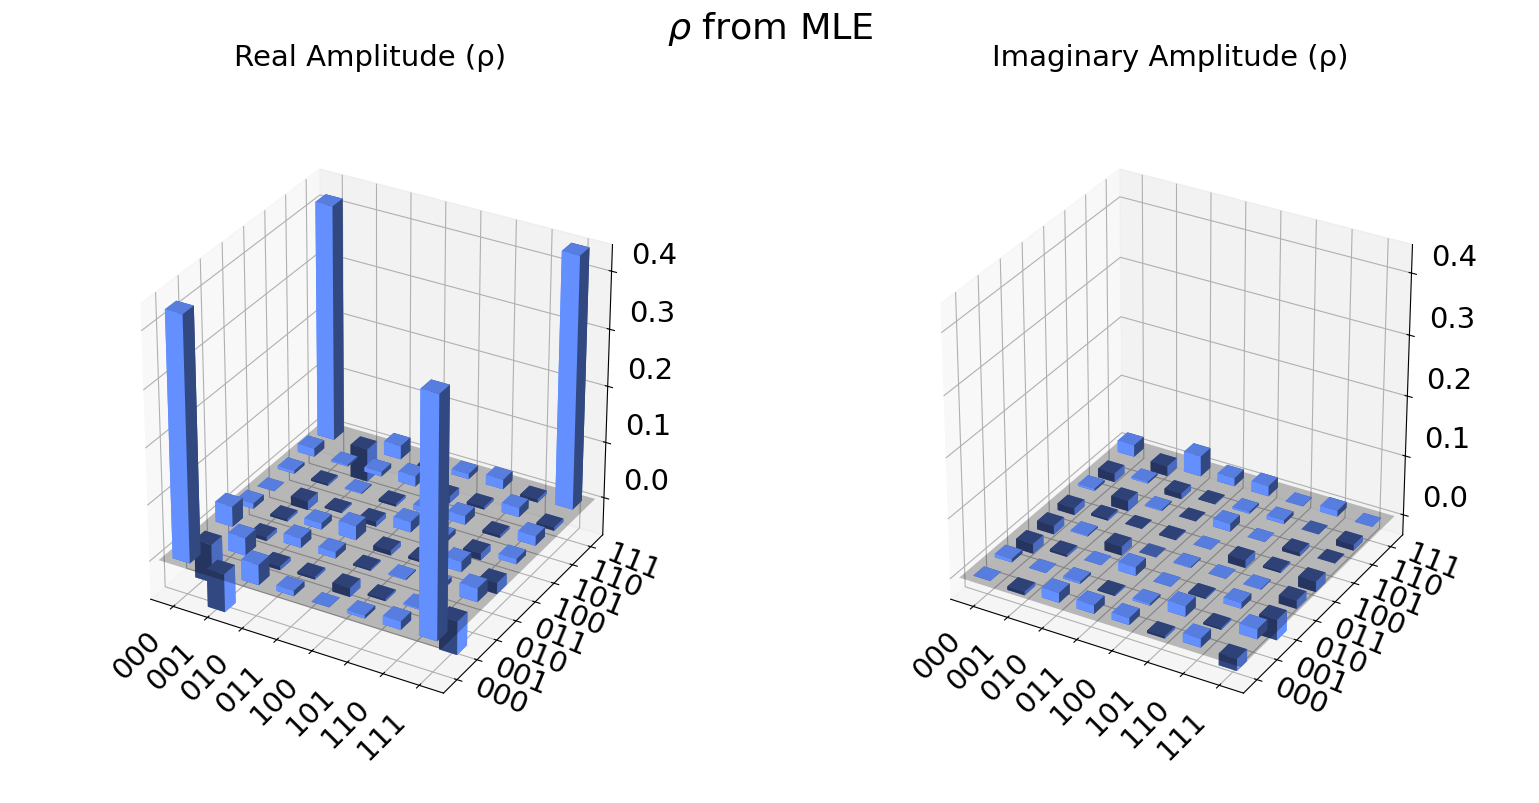

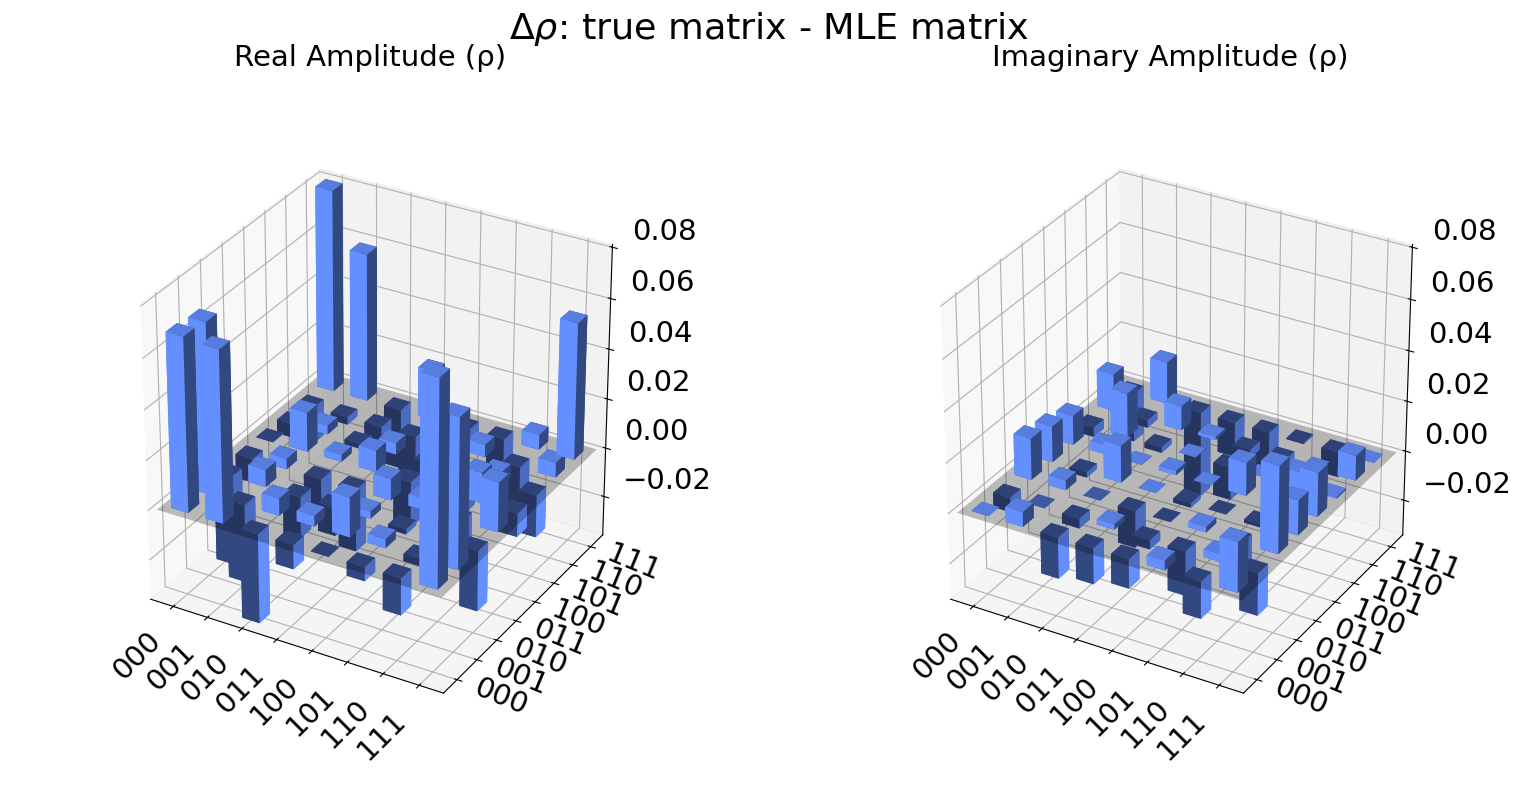

In [60]:
# reconstruct matrix after minimization:
rho_mle = params_to_rho(np.array(m.values), N)

validate_rho(rho_mle)

fig = plot_state_city(rho_mle, title='$\\rho$ from MLE')
display(fig)

rho_diff = rho_true - rho_mle

fig = plot_state_city(rho_diff, title="$\\Delta\\rho$: true matrix - MLE matrix ")
display(fig)

In [61]:
# fidelity 
fq = quantum_fidelity(rho_true, rho_mle)
print(f"quantum fidelity F_q = {fq:.6f}")

# classical fidelity
p_sample = samples_to_empirical_dist(samples, N)
fc    = classical_fidelity(p_exact, p_sample)
print(f"classical fidelity (exact vs sample)  F_c  = {fc:.6f}")

p_mle = povm_probability(rho_mle, N)
# sample_from_rho_mle = sample_povm(p_mle, 1000)
# prob_mle = samples_to_empirical_dist(sample_from_rho_mle, N)
fc    = classical_fidelity(p_exact, p_mle)
print(f"classical fidelity (exact vs mle)  F_c  = {fc:.6f}")

quantum fidelity F_q = 0.857054
classical fidelity (exact vs sample)  F_c  = 0.988477
classical fidelity (exact vs mle)  F_c  = 0.995487


# Variational AutoEncoder

In [62]:
# Convert the samples to one-hot encoding
onehot_samples = samples_to_onehot(samples, N)

In [63]:
# Split the data into training and testing sets (unsupervised: no labels, no stratify)
X_train, X_test = train_test_split(onehot_samples, test_size=0.1, random_state=42)

print(f"Training set size and shape: {len(X_train)} and {X_train.shape}")
print(f"Testing set size and shape: {len(X_test)} and {X_test.shape}")

Training set size and shape: 900 and (900, 12)
Testing set size and shape: 100 and (100, 12)


## Train

In [ ]:
# da riformulare !
# PROJECT_ROOT = Path("/Users/riccardoruggeri/project-sda/statistical-qst-vae")
# RESULTS_ROOT = PROJECT_ROOT / "results"

In [64]:
# Define useful parameters for the VAE training
LATENT_DIM = 16
HIDDEN_DIM = 96
WARMUP_EPOCHS = 50
TOTAL_EPOCHS = 500
BATCH_SIZE = 100
LEARNING_RATE = 1e-3
BETA_MAX = 0.85

In [65]:
# Instantiate and compile the VAE model
vae = VAE(n_qubits=N, latent_dim=LATENT_DIM, hidden=HIDDEN_DIM)
vae.compile(optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE))
vae.build(input_shape=(None, 4*N))

In [66]:
# fit:

# Define callbacks for training
callbacks = [
    KLWarmup(beta_max=BETA_MAX, warmup_epochs=WARMUP_EPOCHS),
    EarlyStopping(monitor='val_reconstruction_loss', mode='min',
                  patience=50, restore_best_weights=True, 
                  start_from_epoch=WARMUP_EPOCHS),
    ReduceLROnPlateau(monitor='val_reconstruction_loss', mode='min',
                      factor=0.5, patience=20, min_lr=1e-6),
]

# fit data
history = vae.fit(
    X_train, X_train,
    epochs=TOTAL_EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test, X_test),
    callbacks=callbacks,
    verbose=1,
)

# save results
# run_dir, checkpoint_path, history_path = set_up_training(experiment_id='vae_training')
# vae.save_weights(checkpoint_path)
# pd.DataFrame(history.history).to_csv(history_path, index=False)

Epoch 1/500
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - kl_loss: 0.4675 - kl_weight: 0.0170 - loss: 4.1629 - reconstruction_loss: 4.1550 - val_kl_loss: 0.5535 - val_loss: 4.1462 - val_reconstruction_loss: 4.1368 - learning_rate: 0.0010
Epoch 2/500
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - kl_loss: 0.8804 - kl_weight: 0.0340 - loss: 3.9201 - reconstruction_loss: 3.8901 - val_kl_loss: 0.9454 - val_loss: 3.9692 - val_reconstruction_loss: 3.9370 - learning_rate: 0.0010
Epoch 3/500
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - kl_loss: 1.7297 - kl_weight: 0.0510 - loss: 3.6075 - reconstruction_loss: 3.5193 - val_kl_loss: 2.0333 - val_loss: 3.5733 - val_reconstruction_loss: 3.4696 - learning_rate: 0.0010
Epoch 4/500
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - kl_loss: 3.9471 - kl_weight: 0.0680 - loss: 3.2230 - reconstruction_loss: 2.9546 - val_kl_loss: 3.9508 - val_loss: 3.2766 - val_reconstruction_loss: 3.0080 - learning_rate: 0.0010
Epoch 5/500
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - kl_loss: 5.1955 - kl_

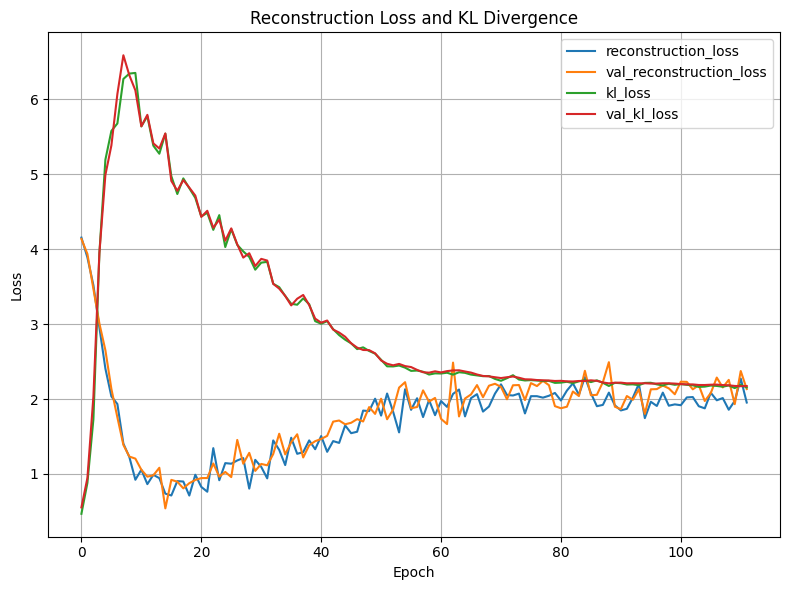

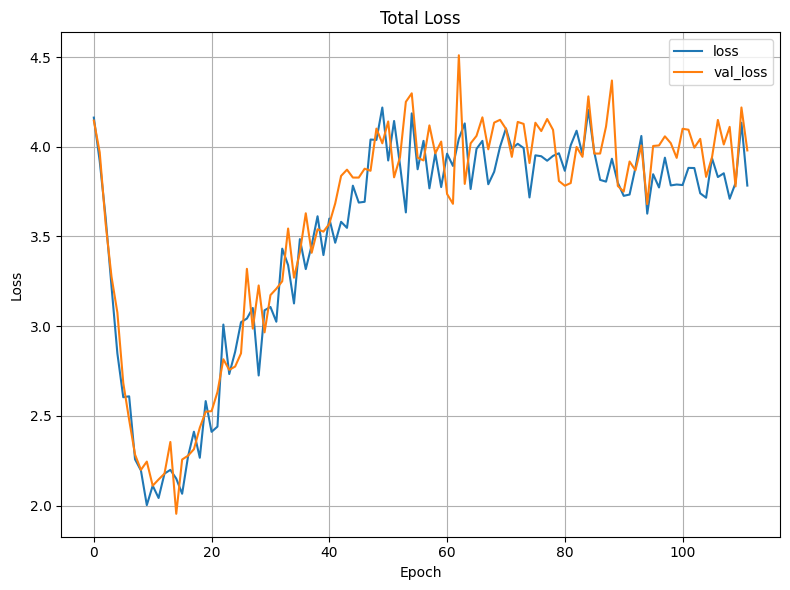

In [67]:
# Plot the training and validation loss curves
plot_reconstruction_and_kl_divergence(history)
plot_total_loss(history)

In [68]:
# fidelity and comparison

outcomes = list(p_exact.keys())

# Generate a large number of samples from the trained VAE model to estimate the distribution it has learned (p_vae)
# Convert the one-hot encoded training data back to samples and compute the empirical distribution (p_train)
p_vae   = vae.predict_dist(n_samples=1000000, batch_size=50_000)
p_unif = {o: 1.0 / len(outcomes) for o in outcomes}
p_train = samples_to_empirical_dist(onehot_to_samples(X_train, N), N)   # less then total number of samples

# Compute the classical fidelity between the distributions
classical_fidelity_floor = classical_fidelity(p_unif, p_exact)
classical_fidelity_vae = classical_fidelity(p_vae, p_exact)
classical_fidelity_train = classical_fidelity(p_train, p_exact)

print("=== Classical Fidelity ===")
print(f"  uniform  vs true : {classical_fidelity_floor:.4f}   <- FLOOR")
print(f"  VAE              vs true : {classical_fidelity_vae:.4f}   <- MODEL")
print(f"  training data    vs true : {classical_fidelity_train:.4f}   <- BASELINE\n")

print("=== GHZ 4 Peaks ===")
print(f"  {'outcome':14s} {'true':>8s} {'VAE':>8s} {'uniform':>9s}")
for o in [(c,) * N for c in range(4)]:
    print(f"  {str(o):14s} {p_exact[o]:8.7f} {p_vae.get(o, 0):8.7f} {1/len(outcomes):9.7f}")

=== Classical Fidelity ===
  uniform  vs true : 0.9510   <- FLOOR
  VAE              vs true : 0.9814   <- MODEL
  training data    vs true : 0.9866   <- BASELINE

=== GHZ 4 Peaks ===
  outcome            true      VAE   uniform
  (0, 0, 0)      0.0625000 0.0508930 0.0156250
  (1, 1, 1)      0.0339279 0.0195520 0.0156250
  (2, 2, 2)      0.0339279 0.0229300 0.0156250
  (3, 3, 3)      0.0339279 0.0164370 0.0156250


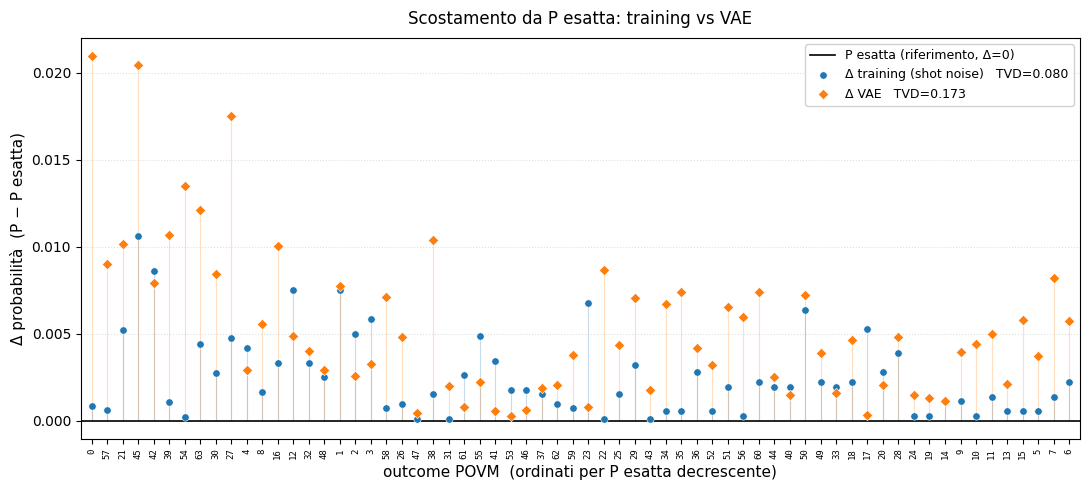

In [49]:
# Plot the distributions (p_exact, p_vae, P_train) over the outcomes
p_true = np.array([p_exact[o]        for o in outcomes])
p_gen  = np.array([p_vae.get(o, 0.0) for o in outcomes]) 
p_train = np.array([p_train.get(o, 0.0) for o in outcomes])
idx = np.arange(len(outcomes))

# Default abs=True
plot_distribution_delta(p_true, p_gen, p_train, idx)

Let's try to reconstruct the density matrix from the vae samples

In [35]:
# use p_vae to reconstruct the matrix

# helper
povm_dict = build_povm(N)
P_vec_vae = pvec_from_pdict(p_vae, N)
T, T_inv = get_overlap_matrix(N)

# perform inverse Born's rule
rho_vae = reconstruct_rho(P_vec_vae, N, T_inv, povm_dict)

# verify reconstructed rho
validate_rho(rho_vae);

# plots
# fig = plot_state_city(rho_vae, title='$\\rho$ direct reconstruction')
# display(fig)

# rho_diff = rho_true - rho_vae

# fig = plot_state_city(rho_diff, title="$\\Delta\\rho$: true matrix - direct reconstruction ")
# display(fig)

# fq = quantum_fidelity(rho_true, rho_vae)
# print(f"quantum fidelity F_q = {fq:.6f}")

  Hermitian:          True
  Tr(rho):            1.00000000
  Pos semi-definite:  False  (min eigval = -4.40e-02)


In [42]:
import numpy as np
from scipy import stats

def evaluate_quantum_chi2(p_povm, p_vae, N):
    """
    Esegue il test del Chi-Quadrato confrontando le probabilità di una POVM
    con quelle generate da un VAE, riscaldate su un numero N di campioni arbitrario.
    
    Parameters:
    -----------
    p_povm : dict
        Dizionario {outcome: prob_esatta} della POVM teorica.
    p_vae  : dict
        Dizionario {outcome: prob_stimata} delle probabilità estratte dal VAE.
    N      : int
        Il numero di campioni (es. dimensione del dataset di addestramento)
        su cui parametrizzare il test.
        
    Returns:
    --------
    dict: Risultati del test (statistica chi2, p-value, gradi di libertà, W di Cohen)
    """
    # Usiamo come riferimento tutti gli outcome possibili definiti dalla POVM
    all_outcomes = list(p_povm.keys())
    
    f_exp = [] # Frequenze attese (POVM)
    f_obs = [] # Frequenze osservate (VAE)
    
    for outcome in all_outcomes:
        # Frequenza attesa teorica riscaldata su N
        f_exp.append(p_povm[outcome] * N)
        
        # Frequenza osservata del VAE riscaldata su N (0 se l'outcome non è mai stato generato)
        prob_vae_val = p_vae.get(outcome, 0.0)
        f_obs.append(prob_vae_val * N)
        
    f_exp = np.array(f_exp)
    f_obs = np.array(f_obs)
    
    # Controllo di sicurezza: normalizzazione delle frequenze per evitare micro-errori di arrotondamento
    # Il Chi-Quadrato richiede che la somma delle frequenze osservate sia uguale a quella delle attese (N)
    f_obs = (f_obs / f_obs.sum()) * N
    f_exp = (f_exp / f_exp.sum()) * N
    
    # Esecuzione del test del Chi-Quadrato
    # ddof=0 significa che i gradi di libertà saranno (numero_categorie - 1)
    chi2_stat, p_value = stats.chisquare(f_obs, f_exp, ddof=0)
    dof = len(all_outcomes) - 1
    
    # Calcolo della W di Cohen (Effect Size) indipendente da N
    # Aiuta a capire l'entità della discrepanza a prescindere da quanto grande sia N
    p_povm_arr = f_exp / N
    p_vae_arr = f_obs / N
    # Evitiamo divisioni per zero se una probabilità POVM è zero
    with np.errstate(divide='ignore', invalid='ignore'):
        cohen_w = np.sqrt(np.nansum(((p_vae_arr - p_povm_arr) ** 2) / p_povm_arr))
    
    return {
        "chi2_stat": chi2_stat,
        "p_value": p_value,
        "dof": dof,
        "cohen_w": cohen_w
    }

N_training = 400
res_train = evaluate_quantum_chi2(p_exact, p_vae, N=N_training)
print(f"--- Test con N = {N_training} (Dimensione Training) ---")
print(f"Statistica Chi2: {res_train['chi2_stat']:.4f}")
print(f"P-value: {res_train['p_value']:.4f} (Se > 0.05 il VAE è compatibile)")
print(f"Effetto (W di Cohen): {res_train['cohen_w']:.4f}\n")




# # Supponiamo una POVM a 3 outcome
# diz_povm = {"|0>": 0.25, "|1>": 0.50, "|2>": 0.25}

# # Probabilità calcolate dal tuo VAE (su 1.000.000 di campioni, quindi molto precise ma non identiche)
# diz_vae  = {"|0>": 0.248, "|1>": 0.501, "|2>": 0.251}

# # Caso 1: Testiamo con N pari al dataset reale di training (es. 5000 campioni)
# N_training = 5000
# res_train = evaluate_quantum_chi2(diz_povm, diz_vae, N=N_training)
# print(f"--- Test con N = {N_training} (Dimensione Training) ---")
# print(f"Statistica Chi2: {res_train['chi2_stat']:.4f}")
# print(f"P-value: {res_train['p_value']:.4f} (Se > 0.05 il VAE è compatibile)")
# print(f"Effetto (W di Cohen): {res_train['cohen_w']:.4f}\n")

# # Caso 2: Esasperiamo il test usando N = 1.000.000 (i campioni generati)
# N_generati = 1000000
# res_gen = evaluate_quantum_chi2(diz_povm, diz_vae, N=N_generati)
# print(f"--- Test con N = {N_generati} (Campioni generati da VAE) ---")
# print(f"Statistica Chi2: {res_gen['chi2_stat']:.4f}")
# print(f"P-value: {res_gen['p_value']:.4e} (Notare come crolla a zero a causa di N grande!)")
# print(f"Effetto (W di Cohen): {res_gen['cohen_w']:.4f} (Resta IDENTICO a prima)")

--- Test con N = 400 (Dimensione Training) ---
Statistica Chi2: 84.3681
P-value: 0.0375 (Se > 0.05 il VAE è compatibile)
Effetto (W di Cohen): 0.4593

